# Importing the required Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, classification_report,
    precision_recall_fscore_support
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

# Loading the Dataset

In [2]:
df = pd.read_csv('synthetic_food_dataset_imbalanced.csv')

# Displaying first 5 rows

In [3]:
df.head(5)

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


# Displaying first bottom 5 rows

In [4]:
df.tail(5)

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
31695,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,81.784216,120.293342,lunch,fried,True,True,Banana
31696,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,192.062481,lunch,raw,False,False,Pizza
31697,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,197.318164,breakfast,grilled,False,False,Pizza
31698,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,152.072098,dinner,grilled,False,False,Pasta
31699,203.952826,5.322650,13.419346,26.686660,14.645211,0.295026,62.468736,38.417093,57.987511,51.156165,113.912626,breakfast,grilled,False,True,Ice Cream


# Checking dataset shape

In [5]:
df.shape

(31700, 16)

# Checking column names

In [6]:
print(df.columns.tolist())

['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size', 'Meal_Type', 'Preparation_Method', 'Is_Vegan', 'Is_Gluten_Free', 'Food_Name']


# Dataset information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

# Statistical summary of dataset

In [8]:
df.describe()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000
mean,273.378441,9.523802,12.476848,28.943200,8.543813,1.904044,335.387611,26.865167,64.213509,48.976592,150.731940
std,111.457160,8.024212,8.425834,12.668795,7.989075,1.779542,319.066106,24.965067,25.390239,20.738749,51.796599
min,60.786204,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.465039,58.575705
25%,210.301731,3.858307,8.245636,25.098800,3.739656,0.741204,63.000654,12.701920,59.984731,38.994221,109.511113
50%,281.774249,9.091637,11.574161,29.681430,5.500479,1.646608,292.525242,23.285882,68.436204,45.613748,151.706514
75%,329.821946,12.683957,15.818611,34.635789,14.426303,2.668750,631.367901,35.132214,75.464697,52.399496,189.083806
max,1289.956763,81.761772,88.619611,140.585537,78.548162,18.891993,2724.236846,260.149443,286.126400,251.837472,554.719629


# Visualize Class Distribution 

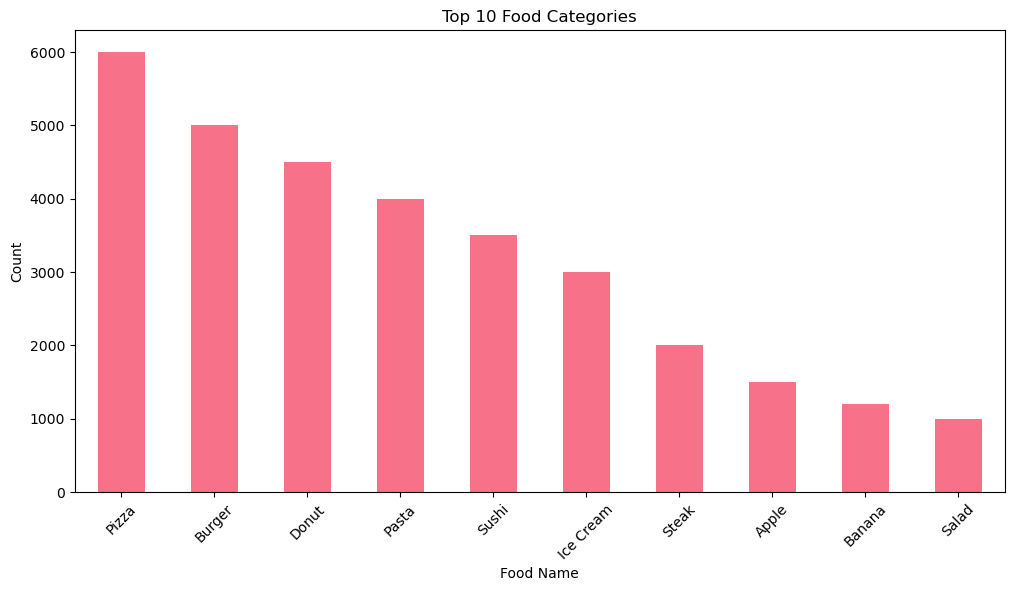

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df["Food_Name"].value_counts().head(20).plot(kind="bar")
plt.title("Top 10 Food Categories")
plt.xlabel("Food Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Checking imbalance ratio

In [14]:
print("\nImbalance ratio (max/min):", 
      df['Food_Name'].value_counts().max() / df['Food_Name'].value_counts().min())


Imbalance ratio (max/min): 6.0


# Missing values

In [15]:
df.isna().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64








# Duplicate rows

In [16]:
df.duplicated().sum()

np.int64(313)

# Removing dupilcates

In [18]:
df = df.drop_duplicates()

# dataset size after removing duplicates

In [21]:
df.shape

(31387, 16)

# Outlier visualization

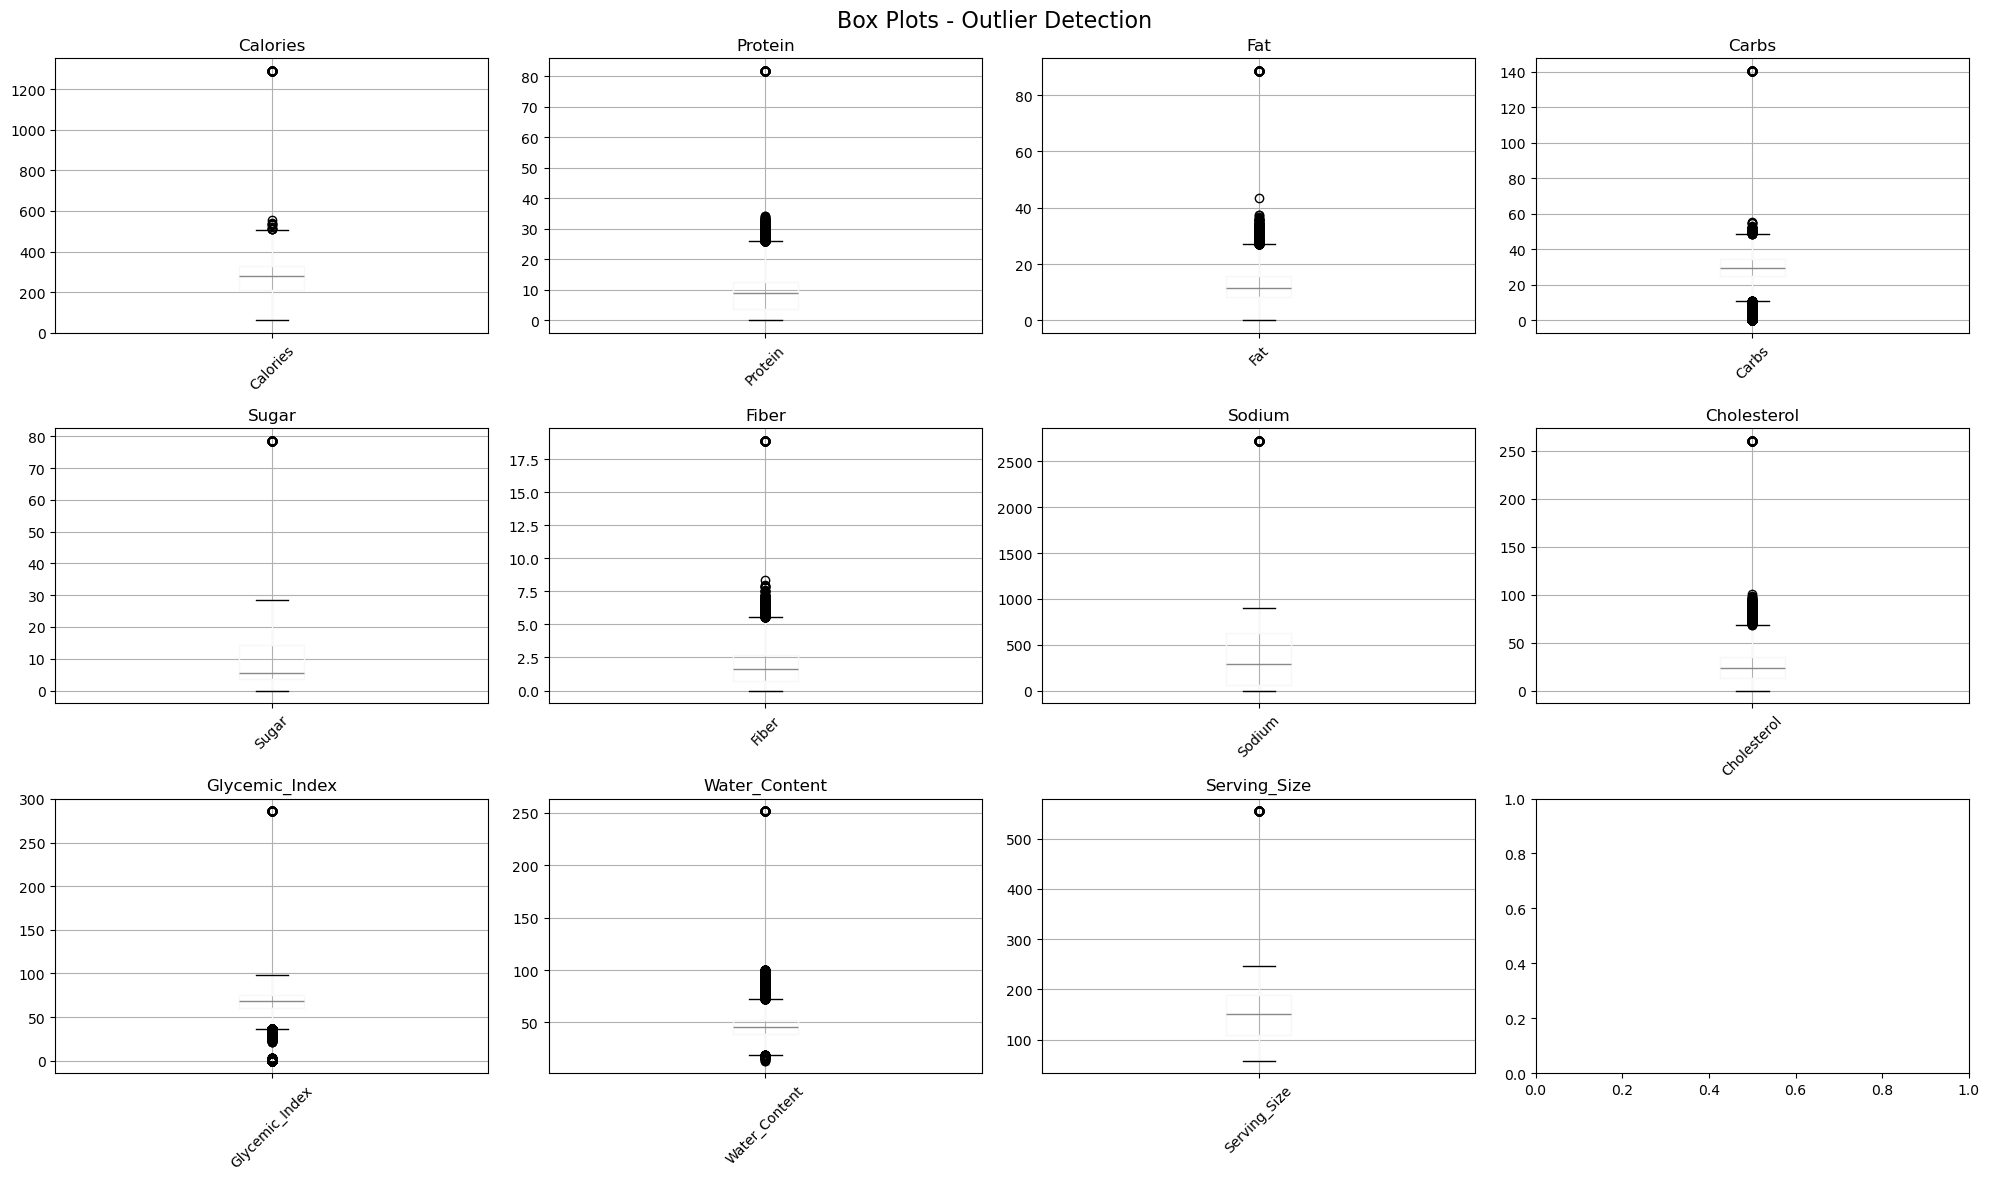

In [23]:
numeric_cols = ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 
                'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Box Plots - Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()

# Checking for correlation¶

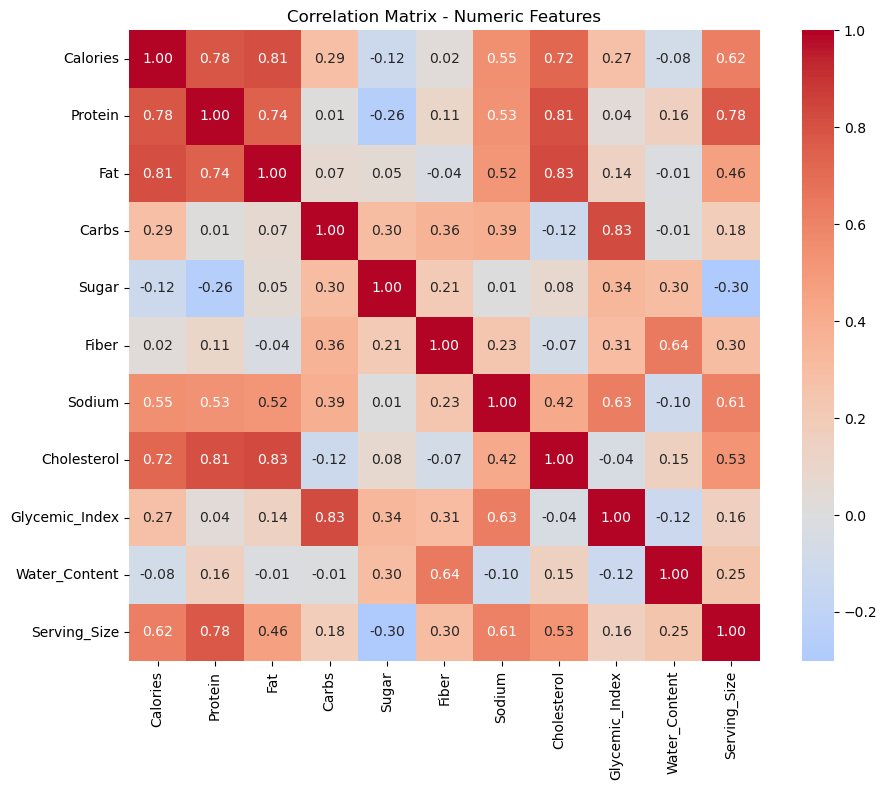

In [24]:
# Select numeric columns for correlation
corr_cols = ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 
                'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

# Encoding

In [25]:
df['Meal_Type'].unique()

array(['dinner', 'snack', 'lunch', 'breakfast'], dtype=object)

In [26]:
df['Preparation_Method'].unique()

array(['fried', 'raw', 'baked', 'grilled'], dtype=object)

In [27]:
# One-hot encoding
ohe_meal = pd.get_dummies(df['Meal_Type'], prefix='Meal')
ohe_prep = pd.get_dummies(df['Preparation_Method'], prefix='Prep')

# Data Preprocessing

In [29]:
# Define numeric columns
num_cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
    'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size'
]

# Outlier capping using (IQR method)

In [30]:

for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    original_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = np.clip(df[col], lower, upper)
    print(f"  {col}: {original_outliers} outliers capped")

  Calories: 94 outliers capped
  Protein: 845 outliers capped
  Fat: 784 outliers capped
  Carbs: 2704 outliers capped
  Sugar: 84 outliers capped
  Fiber: 468 outliers capped
  Sodium: 84 outliers capped
  Cholesterol: 2042 outliers capped
  Glycemic_Index: 3094 outliers capped
  Water_Content: 3315 outliers capped
  Serving_Size: 84 outliers capped


# Handling missing values

imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Feature engineering

In [32]:
# Label encoding for categoricals (better for tree models)
le_meal = LabelEncoder()
le_prep = LabelEncoder()
le_target = LabelEncoder()

In [33]:
df['Meal_Type_enc'] = le_meal.fit_transform(df['Meal_Type'])
df['Preparation_Method_enc'] = le_prep.fit_transform(df['Preparation_Method'])
df['Is_Vegan_enc'] = df['Is_Vegan'].astype(int)
df['Is_Gluten_Free_enc'] = df['Is_Gluten_Free'].astype(int)


In [34]:
# Final feature list (15 features)
feature_cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
    'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
    'Meal_Type_enc', 'Preparation_Method_enc', 'Is_Vegan_enc', 'Is_Gluten_Free_enc'
]

X = df[feature_cols]
y = df['Food_Name']
y_enc = le_target.fit_transform(y)

# Train test split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

In [36]:
X_train

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type_enc,Preparation_Method_enc,Is_Vegan_enc,Is_Gluten_Free_enc
26939,226.530223,4.615602,20.543278,32.468006,20.651617,1.279977,271.821982,18.866186,76.128867,33.086092,85.984662,2,1,0,0
9338,371.962012,11.195000,12.756344,29.790322,7.694205,1.327864,593.002540,25.192787,88.980647,33.147623,190.351582,0,2,0,0
7273,282.878565,11.002096,13.444578,30.295757,4.314869,1.723142,561.129238,20.222647,77.149037,41.787129,213.677899,0,3,0,0
2978,163.451927,10.371615,5.746256,33.731485,4.711974,0.648843,308.572517,18.262370,74.940556,49.651043,151.900469,0,2,0,1
9825,214.677473,2.111975,9.569797,28.262147,20.299308,0.602908,91.047011,46.088399,59.359471,49.075238,94.488642,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2266,402.428301,25.883664,26.245669,10.812696,0.127039,0.000000,88.688393,68.550856,36.792935,47.626762,184.060990,1,1,0,1
6615,291.666101,13.734632,19.739960,36.801911,8.335944,0.901358,689.452933,34.406859,59.803592,51.678155,183.829860,1,0,0,0
12892,310.505998,13.187346,12.479998,36.416259,5.711321,2.548242,651.662210,15.693981,74.648548,45.647099,202.395960,2,0,0,0
8428,321.052286,11.628968,15.996992,28.442865,5.227237,2.047279,645.270102,33.177556,86.653263,31.073613,215.541207,0,3,0,0


# scaling

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
X_train_scaled

array([[-0.48905872, -0.73655384,  1.30169415, ..., -0.44265383,
        -0.3638162 , -0.79161353],
       [ 1.17541375,  0.32659195,  0.10122627, ...,  0.44701198,
        -0.3638162 , -0.79161353],
       [ 0.15585024,  0.29542107,  0.20732733, ...,  1.3366778 ,
        -0.3638162 , -0.79161353],
       ...,
       [ 0.47204728,  0.64852938,  0.05862358, ..., -1.33231964,
        -0.3638162 , -0.79161353],
       [ 0.59274995,  0.39671549,  0.60081871, ...,  1.3366778 ,
        -0.3638162 , -0.79161353],
       [ 0.04917729,  0.57098509,  0.31351354, ..., -0.44265383,
        -0.3638162 , -0.79161353]])

# PCA

In [39]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [40]:
print("Original features:", X.shape[1])

Original features: 15


In [41]:
print("PCA components (95% variance):", X_train_pca.shape[1])

PCA components (95% variance): 9


In [42]:
print("Train shape:", X_train_pca.shape)
print("Test shape:", X_test_pca.shape)

Train shape: (25109, 9)
Test shape: (6278, 9)


# Training

In [44]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(random_state=42, probability=True),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
model_objects = {}
best_model = None
best_name = ""
best_acc = 0.0

print("Training 7 models...\n")
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    model_objects[name] = model
    
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    precision_macro, recall_macro, _, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro'
    )
    cv_scores = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision_macro': precision_macro,
        'Recall_macro': recall_macro,
        'F1_macro': f1_macro,
        'CV_5fold': cv_scores.mean()
    })
    
    print(f"{name}: {acc:.3f} accuracy, {cv_scores.mean():.3f} CV")
    
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(f"\n🏆 BEST MODEL: {best_name} ({best_acc:.3f})")
results_df

Training 7 models...

Logistic Regression: 0.990 accuracy, 0.987 CV
Decision Tree: 0.980 accuracy, 0.978 CV
Random Forest: 0.984 accuracy, 0.983 CV
KNN: 0.987 accuracy, 0.986 CV
SVM: 0.991 accuracy, 0.989 CV
XGBoost: 0.988 accuracy, 0.987 CV
Gradient Boosting: 0.987 accuracy, 0.986 CV

🏆 BEST MODEL: SVM (0.991)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,CV_5fold
4,SVM,0.990602,0.992479,0.992218,0.992337,0.989366
0,Logistic Regression,0.990443,0.990900,0.990876,0.990876,0.987455
5,XGBoost,0.987894,0.989609,0.989708,0.989651,0.986817
3,KNN,0.986779,0.988741,0.988034,0.988370,0.985862
6,Gradient Boosting,0.986620,0.987024,0.987103,0.987041,0.985862
2,Random Forest,0.984231,0.985114,0.984933,0.985008,0.982954
1,Decision Tree,0.979771,0.978676,0.978500,0.978566,0.977578


In [ ]:
# classification_report

In [45]:
y_best_pred = best_model.predict(X_test_pca)
print(classification_report(y_test, y_best_pred, target_names=le_target.classes_))

              precision    recall  f1-score   support

       Apple       0.99      0.99      0.99       297
      Banana       0.99      0.99      0.99       239
      Burger       0.99      0.97      0.98       988
       Donut       1.00      1.00      1.00       893
   Ice Cream       1.00      1.00      1.00       594
       Pasta       0.99      0.99      0.99       795
       Pizza       0.98      0.99      0.98      1183
       Salad       1.00      0.99      1.00       199
       Steak       1.00      1.00      1.00       398
       Sushi       1.00      1.00      1.00       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278



In [ ]:
# Confusion matrix

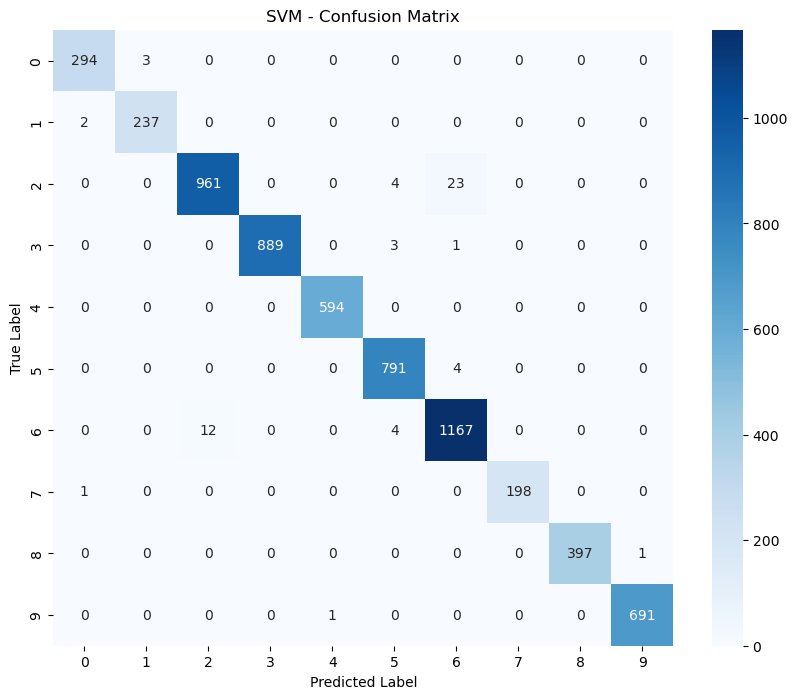

In [46]:

cm = confusion_matrix(y_test, y_best_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'{best_name} - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Saving the model

In [48]:

joblib.dump(scaler, 'scaler.joblib')
joblib.dump(pca, 'pca.joblib')
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(le_meal, 'le_meal.joblib')
joblib.dump(le_prep, 'le_prep.joblib')
joblib.dump(le_target, 'le_target.joblib')
joblib.dump(feature_cols, 'feature_cols.joblib')

print("✅ ALL FILES SAVED:")
print("- scaler.joblib")
print("- pca.joblib") 
print("- best_model.joblib")
print("- le_meal.joblib")
print("- le_prep.joblib")
print("- le_target.joblib")
print("- feature_cols.joblib")
print("Streamlit app.py can now load these for FAST predictions")

✅ ALL FILES SAVED:
- scaler.joblib
- pca.joblib
- best_model.joblib
- le_meal.joblib
- le_prep.joblib
- le_target.joblib
- feature_cols.joblib
Streamlit app.py can now load these for FAST predictions
